**Prova con Mach-Zehnder**

In [1]:
import pandas as pd
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns  ## better plots 
import sax  ## dizionario matrice scattering e circuiti
from jax.typing import ArrayLike

In [2]:
from simphony.libraries import siepic

È sempre possibile chiamare la funzione dei modelli in SAX senza argomenti poichè sono presenti di default e possiamo così ispezionarele porte del modello

In [3]:
print(sax.get_ports(siepic.y_branch))

('port_1', 'port_2', 'port_3')


**Passiamo a creare il circuito del MZI senza grating coupler**

In [4]:
mzi, info = sax.circuit(
    netlist={
        "instances": {
            "splitter": "ybranch",
            "wg_l": "wg",
            "wg_s": "wg",
            "combiner": "ybranch",
        },
        "connections": {
            "splitter,port 2": "wg_l,o0",
            "splitter,port 3": "wg_s,o0",
            "wg_l,o1": "combiner,port 2",
            "wg_s,o1": "combiner,port 3",
        },
        "ports": {
            "in": "splitter,port 1",
            "out": "combiner,port 1",
        },
    },
    models={
        "ybranch": siepic.y_branch,
        "wg": siepic.waveguide,
    }
)

La netlist è un dizionario composto di 3 campi: istanze (cosa vi legge l'operatore), connessioni (interne tra le porte dei componenti), porte esposte; si poggia sul dizionario che definisce i modelli (nomi istanze -> libreria.modello)

le modifiche al dizionario le si può passare dizionari di argomento e valore in una funzione, __lo valuto successivamente__

I parametri che vogliamo cambiare nl circuito sono esclusivamente le lunghezze delle guide dei due bracci del MZI:

In [59]:
## innanzitutto impostiamo i valori di lunghezza d'onda da valutare con l'interferometro
wl = jnp.linspace(1.5, 1.6, 1000) ## tra 1.5 e 1.6 μm con 1000 campioni

In [60]:
## ora cambiamo le lunghezze delle guide nel circuito richiamando le istanze del circuito
S = mzi(wl=wl, wg_l={"length": 150.0}, wg_s={"length": 159.5})
## otteniamo il dizionario di prametri di scattering

Per leggere la potenza trasmessa dall'input all output del dispositivo operiamo il quadrato dell'ampiezza del paramtero di interesse.

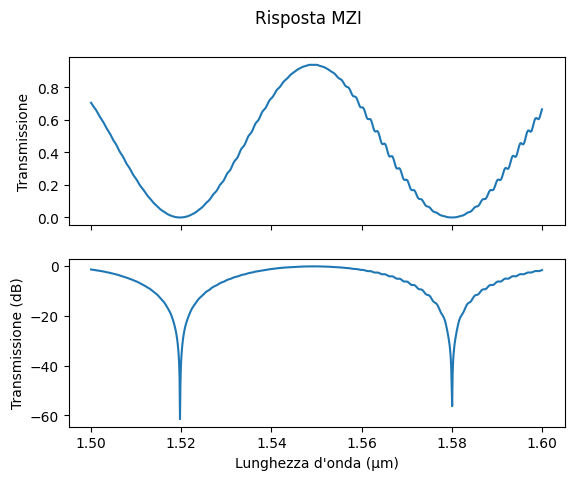

In [61]:
mag = jnp.abs(S["out", "in"])**2 ## S_21

fig, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(wl, mag)
axs[0].set_ylabel("Transmissione")
axs[1].plot(wl, 10*jnp.log10(mag))
axs[1].set_ylabel("Transmissione (dB)")
axs[1].set_xlabel("Lunghezza d'onda (µm)")
plt.suptitle("Risposta MZI")
plt.show()

In [54]:
## PROVE GENERICHE
wl = 1.58;
## wl = jnp.linspace(1.5, 1.6, 1000)
S = mzi(wl=wl, wg_l={"length": 296.64}, wg_s={"length": 296.64})
mag = jnp.abs(S["out", "in"])**2
print(S["out", "in"]) ## PARAMETRO S IN AMPIEZZA TRA USCITA E INGRESSO
print(mag)  ## È LA POTENZA

[-0.0164874-0.96861925j]
[0.93849509]


Un altro metodo di simulazione prevede l'uso di classi, ad esempio possiamo fare una simulazione di tipo sweep su un range di lunghezze d'onda impostando un laser ideale a monte del dispositivo e leggendone l'uscita

In [9]:
## carichiamo la libreria
from simphony.classical import ClassicalSim

In [10]:
## impostiamo le lunghezze d'onda da simulare
wl = jnp.linspace(1.5,1.6,1000)

In [11]:
sim = ClassicalSim(ckt=mzi, wl=wl, wg_l={"length":150.0}, wg_s={"length":50.0})
laser = sim.add_laser(ports=["in"], power=1.0)
detector = sim.add_detector(ports=["out"])

In [12]:
result = sim.run()

<Axes: xlabel='Wavelength (um)', ylabel='Power (mW)'>

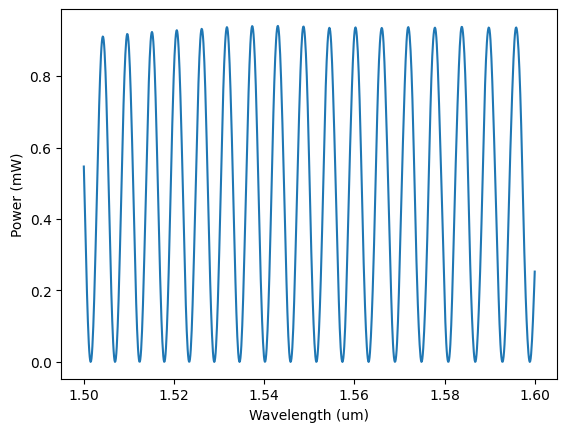

In [13]:
result.detectors["out"].plot()

**Isolo il picco centrale nella precedente simulazione**

<Axes: xlabel='Wavelength (um)', ylabel='Power (mW)'>

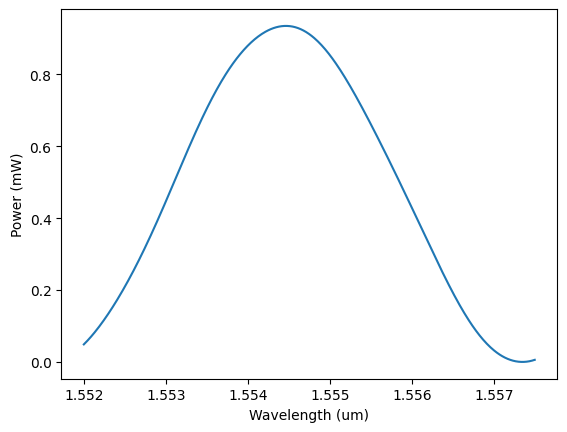

In [14]:
wl = jnp.linspace(1.552, 1.5575,500)
sim = ClassicalSim(ckt=mzi, wl=wl, wg_l={"length":150.0}, wg_s={"length":50.0})
laser = sim.add_laser(ports=["in"], power=1.0)
detector = sim.add_detector(ports=["out"])
result = sim.run()
result.detectors["out"].plot()

### ora includiamo la guida d'onda con indice di rifrazione come ramo ###

In [15]:
from simphony.libraries import ideal

In [16]:
ideal.waveguide?

Signature:
ideal.waveguide(
    *,
    wl: Union[jax.Array, numpy.ndarray, numpy.bool, numpy.number, bool, int, float, complex, jax._src.literals.TypedNdArray] = 1.55,
    wl0: float = 1.55,
    neff: float = 2.34,
    ng: float = 3.4,
    length: float = 10.0,
    loss: float = 0.0,
) -> dict[tuple[str, str], jaxtyping.Complex[Array, '...']]
Docstring:
A simple straight waveguide model.

Port names are "o0" and "o1".

Parameters
----------
wl : ArrayLike or float
    Wavelength in microns (default 1.55).
wl0 : float
    Center wavelength in microns (default 1.55).
neff : float
    Effective index (default 2.34).
ng : float
    Group index (default 3.4).
length : float
    Length in microns (default 10.0).
loss : float
    Loss in dB/cm (default 0.0).

Returns:
    A dictionary of scattering matrices.
File:      ~/miniconda3/lib/python3.13/site-packages/simphony/libraries/ideal.py
Type:      function

In [17]:
mzi_NI, info = sax.circuit(
    netlist={
        "instances": {
            "splitter": "ybranch",
            "wg_1": "wg_siepic",
            "wg_2": "wg_ideal",
            "combiner": "ybranch",
        },
        "connections": {
            "splitter,port 2": "wg_1,o0",
            "splitter,port 3": "wg_2,o0",
            "wg_1,o1": "combiner,port 2",
            "wg_2,o1": "combiner,port 3",
        },
        "ports": {
            "in": "splitter,port 1",
            "out": "combiner,port 1",
        },
    },
    models={
        "ybranch": siepic.y_branch,
        "wg_siepic": siepic.waveguide,
        "wg_ideal": ideal.waveguide,
    }
)

In [64]:
## PROVE GENERICHE
wl = 1.53;
## wl = jnp.linspace(1.5, 1.6, 1000)
S = mzi_NI(wl=wl, wg_1={"length": 100.0}, wg_2={"length": 100.0})
mag = jnp.abs(S["out", "in"])**2
print(S["out", "in"]) ## PARAMETRO S IN AMPIEZZA TRA USCITA E INGRESSO
print(mag)  ## È LA POTENZA

[0.00671856+0.07793128j]
[0.00611842]


In [19]:
## PROVE GENERICHE
wl = 1.55;
## wl = jnp.linspace(1.5, 1.6, 1000)
S = mzi_NI(wl=wl, wg_1={"length": 200.0}, wg_2={"length": 100.0})
mag = jnp.abs(S["out", "in"])**2
print(S["out", "in"]) ## PARAMETRO S IN AMPIEZZA TRA USCITA E INGRESSO
print(mag)  ## È LA POTENZA

[0.24938086+0.03170948j]
[0.06319631]


In [71]:
wl = jnp.linspace(1.5, 1.6, 1000) ## tra 1.5 e 1.6 μm con 1000 campioni
S = mzi_NI(wl=wl, wg_1={"length": 100.0}, wg_2={"length": 106.50})

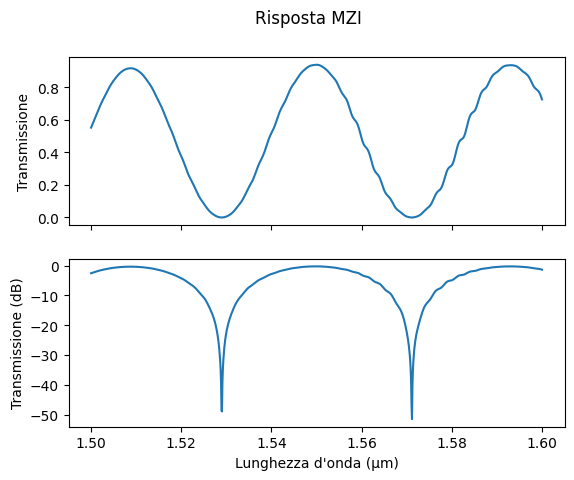

In [72]:
mag = jnp.abs(S["out", "in"])**2 ## S_21

fig, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(wl, mag)
axs[0].set_ylabel("Transmissione")
axs[1].plot(wl, 10*jnp.log10(mag))
axs[1].set_ylabel("Transmissione (dB)")
axs[1].set_xlabel("Lunghezza d'onda (µm)")
plt.suptitle("Risposta MZI")
plt.show()

**indice di rifrazione del modello pari a 2.34, materiale non determinabile.
neff_Si=3.4 aggiornare anche l'indice di gruppo definico come ng=c/vg**

In [22]:
## carichiamo la libreria
from simphony.classical import ClassicalSim
## impostiamo le lunghezze d'onda da simulare
wl = jnp.linspace(1.5,1.6,800)
sim = ClassicalSim(ckt=mzi, wl=wl, wg_1={"length":150.0}, wg_2={"length":100.0})
laser = sim.add_laser(ports=["in"], power=1.0)
detector = sim.add_detector(ports=["out"])

In [23]:
result = sim.run()

<Axes: xlabel='Wavelength (um)', ylabel='Power (mW)'>

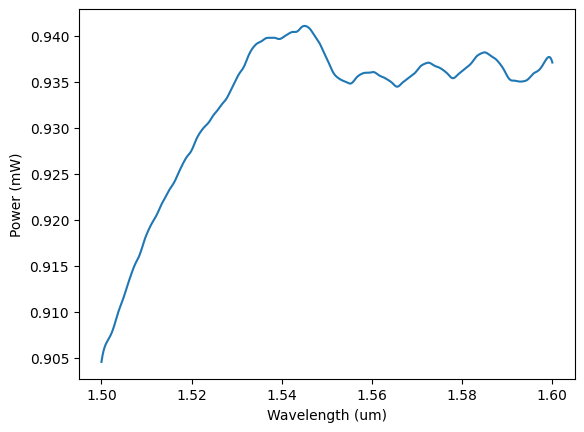

In [24]:
result.detectors["out"].plot()

In [25]:


## errore con wg ideal lib
#TypeError                                 Traceback (most recent call last)
#Cell In[33], line 1
#----> 1 sim1 = ClassicalSim(wg_1, wl=1.55)
#      2 laser = sim.add_laser(ports=['o0'], power= 1.0)

#File ~/miniconda3/lib/python3.13/site-packages/simphony/classical.py:143, in ClassicalSim.__init__(self, ckt, **kwargs)
#    127 """Initialize the classical simulation.
#    128 
#    129 Parameters
#   (...)    140 >>> sim = ClassicalSim(ckt=mzi, wl=wl, top={"length": 150.0}, bottom={"length": 50.0})
#    141 """
#    142 # TODO: Add shot noise option to classical simulation
#--> 143 ckt = partial(ckt, **kwargs)
#    144 if "wl" not in kwargs:
#    145     raise ValueError("Must specify 'wl' (wavelengths to simulate).")

#TypeError: the first argument must be callable
##